In [ ]:
!pip install -q scikit-fuzzy

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('sales_data.csv')

In [ ]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [ ]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [ ]:
print(df.shape)
print(df.head())
print(df.info())


(76000, 16)
         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001  Electronics  North              195   
1  2022-01-01     S001      P0002     Clothing  North              117   
2  2022-01-01     S001      P0003     Clothing  North              247   
3  2022-01-01     S001      P0004  Electronics  North              139   
4  2022-01-01     S001      P0005    Groceries  North              152   

   Units Sold  Units Ordered  Price  Discount Weather Condition  Promotion  \
0         102            252  72.72         5             Snowy          0   
1         117            249  80.16        15             Snowy          1   
2         114            612  62.94        10             Snowy          1   
3          45            102  87.63        10             Snowy          0   
4          65            271  54.41         0             Snowy          0   

   Competitor Pricing Seasonality  Epidemic  Demand  
0               85.7

In [ ]:

print(df.duplicated().sum())

0


In [ ]:
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Price,0
Discount,0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
display(df.head())

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,DayOfWeek,IsWeekend
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,5,1
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,5,1
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,5,1
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,5,1
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64,2024,1,1,0
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137,2024,1,1,0
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68,2024,1,1,0
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84,2024,1,1,0


In [ ]:
y = df['Units Sold']

train_size = int(0.8 * len(df))
df_train_raw = df.iloc[:train_size].copy()
df_test_raw  = df.iloc[train_size:].copy()
y_train_raw  = y.iloc[:train_size]


for col in ['Store ID', 'Product ID']:
    means = df_train_raw.groupby(col)['Units Sold'].mean()
    df_train_raw[f'{col}_encoded'] = df_train_raw[col].map(means)
    df_test_raw[f'{col}_encoded']  = df_test_raw[col].map(means).fillna(means.mean())

print('Target encoding done.')

Target encoding done.


In [ ]:
columns_to_drop = ['Store ID', 'Product ID', 'Demand']

df_train = df_train_raw.drop(columns=columns_to_drop, errors='ignore')
df_test  = df_test_raw.drop(columns=columns_to_drop, errors='ignore')

df = df.drop(columns=columns_to_drop, errors='ignore')

print('Remaining columns:', df_train.columns.tolist())

Remaining columns: ['Date', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Year', 'Month', 'DayOfWeek', 'IsWeekend', 'Store ID_encoded', 'Product ID_encoded']


In [ ]:
categorical_cols = ['Weather Condition', 'Seasonality', 'Category']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
df_train = pd.get_dummies(df_train, columns=categorical_cols, drop_first=True)
df_test  = pd.get_dummies(df_test,  columns=categorical_cols, drop_first=True)
df_test  = df_test.reindex(columns=df_train.columns, fill_value=0)
df

,Date,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,...,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter,Category_Electronics,Category_Furniture,Category_Groceries,Category_Toys
0,2022-01-01,North,195,102,252,72.72,5,0,85.73,0,...,False,True,False,False,False,True,True,False,False,False
1,2022-01-01,North,117,117,249,80.16,15,1,92.02,0,...,False,True,False,False,False,True,False,False,False,False
2,2022-01-01,North,247,114,612,62.94,10,1,60.08,0,...,False,True,False,False,False,True,False,False,False,False
3,2022-01-01,North,139,45,102,87.63,10,0,85.19,0,...,False,True,False,False,False,True,True,False,False,False
4,2022-01-01,North,152,65,271,54.41,0,0,51.63,0,...,False,True,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,North,233,63,0,29.80,5,0,32.23,0,...,False,True,False,False,False,True,False,False,False,True
75996,2024-01-30,North,137,115,141,42.92,5,0,40.73,0,...,False,True,False,False,False,True,False,False,False,True
75997,2024-01-30,North,197,44,0,17.81,10,0,19.41,0,...,False,True,False,False,False,True,False,False,False,False
75998,2024-01-30,North,125,58,0,151.72,0,0,143.71,0,...,False,True,False,False,False,True,False,True,False,False


In [ ]:
df = df.drop(columns=['Region'], errors='ignore')
df_train = df_train.drop(columns=['Region'], errors='ignore')
df_test  = df_test.drop(columns=['Region'],  errors='ignore')

display(df_train.head())
print(df_train.shape)


,Date,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Year,...,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter,Category_Electronics,Category_Furniture,Category_Groceries,Category_Toys
0,2022-01-01,195,102,252,72.72,5,0,85.73,0,2022,...,False,True,False,False,False,True,True,False,False,False
1,2022-01-01,117,117,249,80.16,15,1,92.02,0,2022,...,False,True,False,False,False,True,False,False,False,False
2,2022-01-01,247,114,612,62.94,10,1,60.08,0,2022,...,False,True,False,False,False,True,False,False,False,False
3,2022-01-01,139,45,102,87.63,10,0,85.19,0,2022,...,False,True,False,False,False,True,True,False,False,False
4,2022-01-01,152,65,271,54.41,0,0,51.63,0,2022,...,False,True,False,False,False,True,False,False,True,False


(60800, 25)


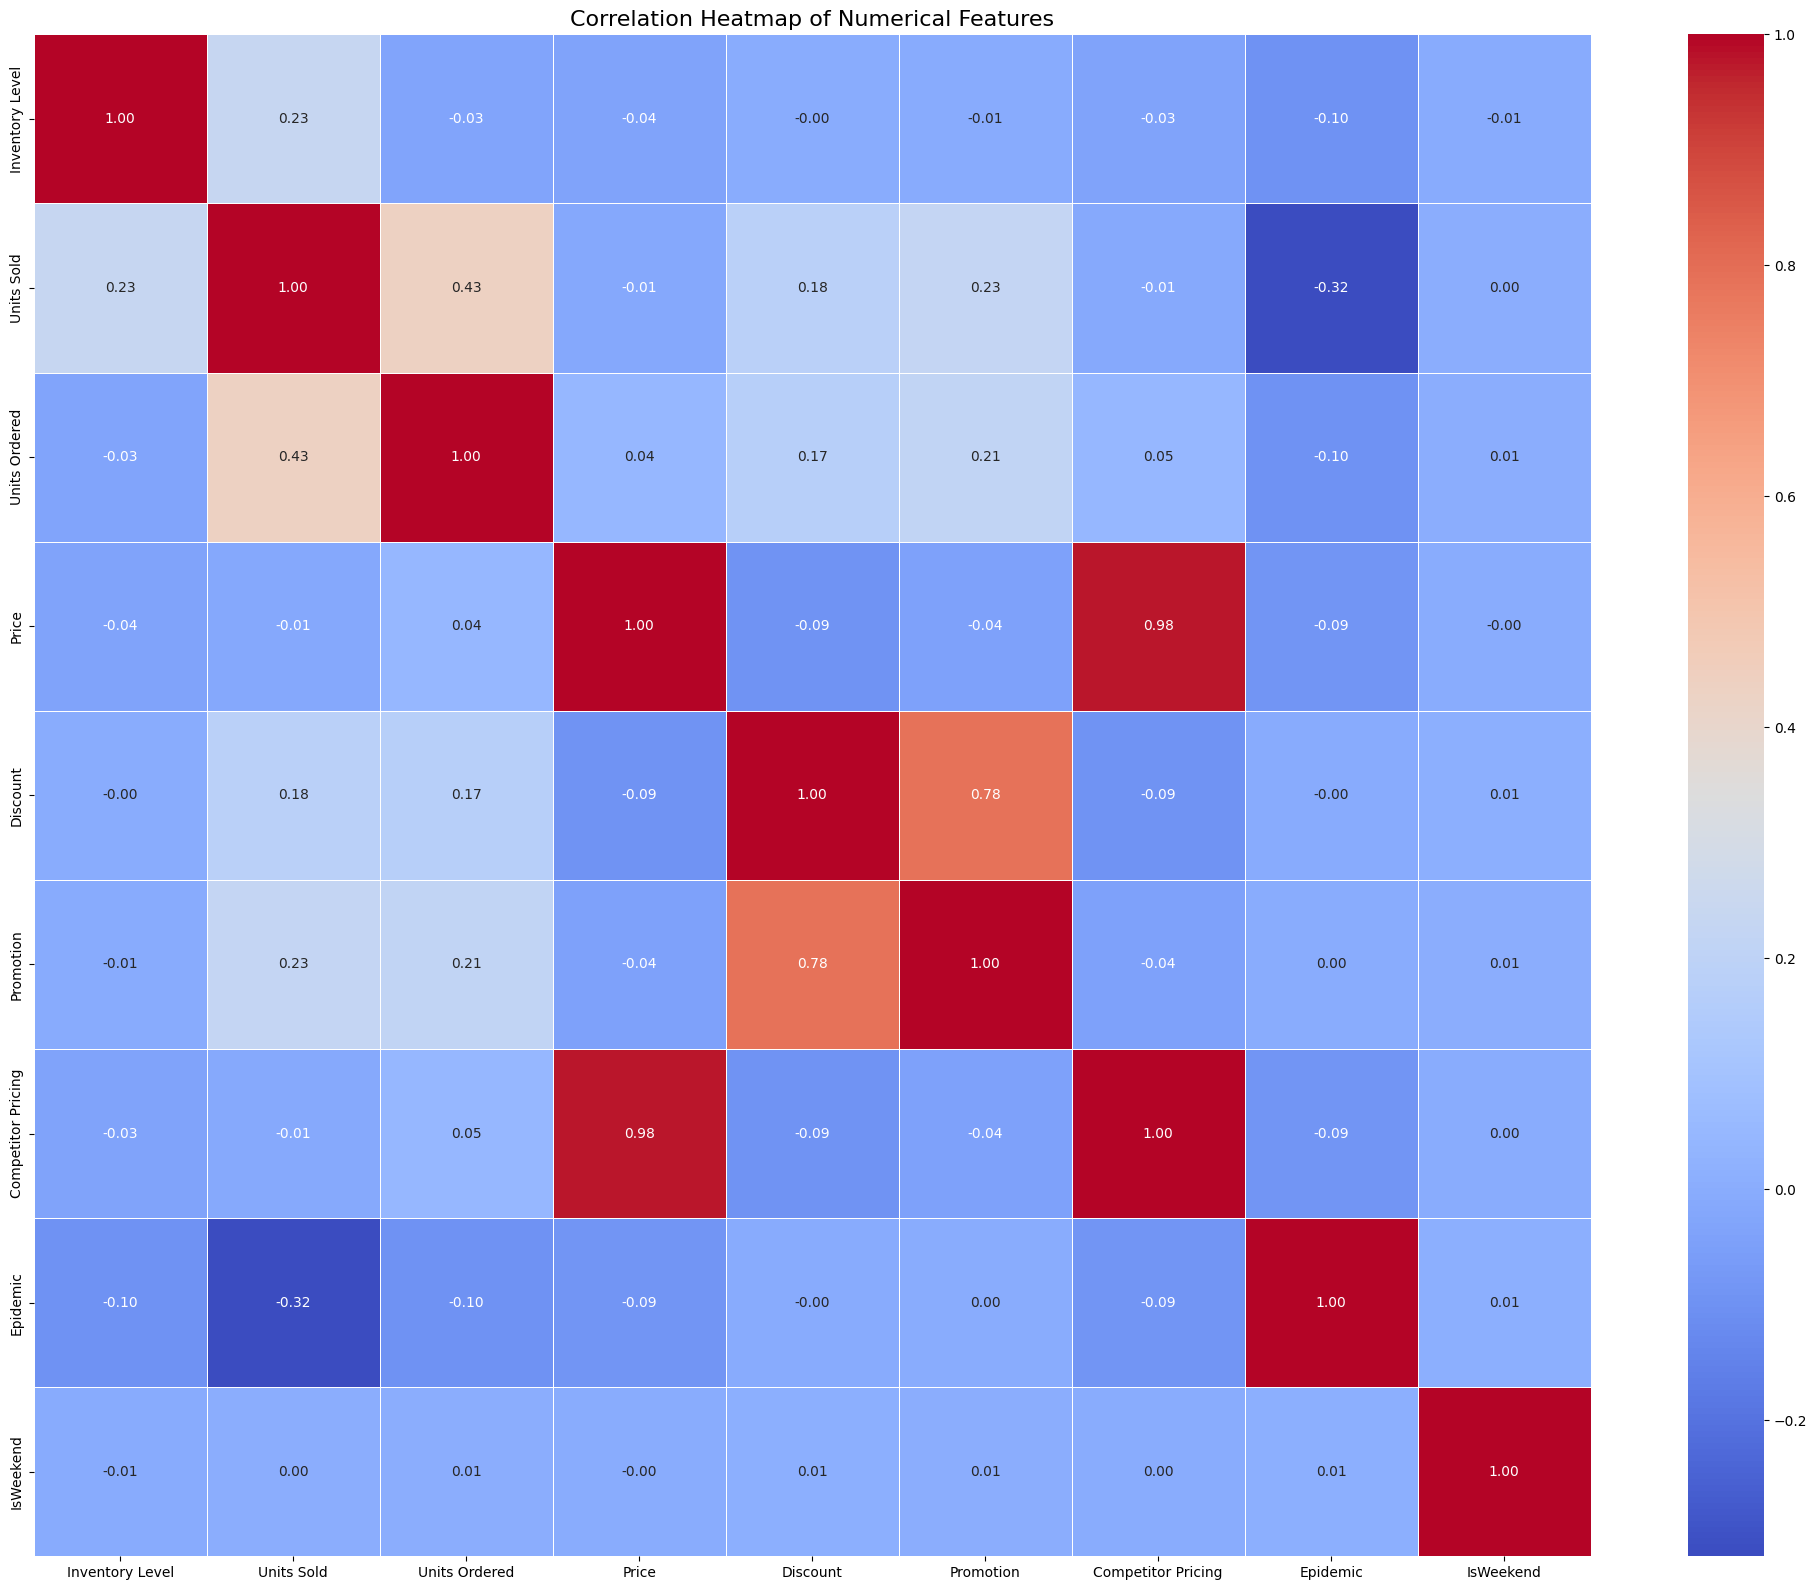

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(20, 16))
sns.heatmap(numerical_df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
df = df.drop(columns=['Competitor Pricing'])
print(df.shape)
display(df.head())

(76000, 22)


,Date,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Epidemic,Year,Month,...,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter,Category_Electronics,Category_Furniture,Category_Groceries,Category_Toys
0,2022-01-01,195,102,252,72.72,5,0,0,2022,1,...,False,True,False,False,False,True,True,False,False,False
1,2022-01-01,117,117,249,80.16,15,1,0,2022,1,...,False,True,False,False,False,True,False,False,False,False
2,2022-01-01,247,114,612,62.94,10,1,0,2022,1,...,False,True,False,False,False,True,False,False,False,False
3,2022-01-01,139,45,102,87.63,10,0,0,2022,1,...,False,True,False,False,False,True,True,False,False,False
4,2022-01-01,152,65,271,54.41,0,0,0,2022,1,...,False,True,False,False,False,True,False,False,True,False


In [ ]:
print(df[['Units Ordered', 'Units Sold']].corr())

               Units Ordered  Units Sold
Units Ordered       1.000000    0.433943
Units Sold          0.433943    1.000000


In [ ]:
print(df[['Units Ordered', 'Units Sold']].corr())

               Units Ordered  Units Sold
Units Ordered       1.000000    0.433943
Units Sold          0.433943    1.000000


In [ ]:
df = df.drop(columns=['Units Ordered'])
print(df.shape)
display(df.head())

(76000, 21)


,Date,Inventory Level,Units Sold,Price,Discount,Promotion,Epidemic,Year,Month,DayOfWeek,...,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter,Category_Electronics,Category_Furniture,Category_Groceries,Category_Toys
0,2022-01-01,195,102,72.72,5,0,0,2022,1,5,...,False,True,False,False,False,True,True,False,False,False
1,2022-01-01,117,117,80.16,15,1,0,2022,1,5,...,False,True,False,False,False,True,False,False,False,False
2,2022-01-01,247,114,62.94,10,1,0,2022,1,5,...,False,True,False,False,False,True,False,False,False,False
3,2022-01-01,139,45,87.63,10,0,0,2022,1,5,...,False,True,False,False,False,True,True,False,False,False
4,2022-01-01,152,65,54.41,0,0,0,2022,1,5,...,False,True,False,False,False,True,False,False,True,False


In [ ]:
df_full = df.copy()
df_full['Units_Sold_raw'] = df['Units Sold'] if 'Units Sold' in df.columns else y.values

date_col = df_full.get('Date', None)

df_train = df_train.copy()
df_test  = df_test.copy()

y_series = y.reset_index(drop=True)
lag_7  = y_series.shift(7).fillna(y_series.mean())
lag_30 = y_series.shift(30).fillna(y_series.mean())
roll7  = y_series.shift(1).rolling(7,  min_periods=1).mean()
roll30 = y_series.shift(1).rolling(30, min_periods=1).mean()
roll7s = y_series.shift(1).rolling(7,  min_periods=1).std().fillna(0)

df_train['lag_7']        = lag_7.iloc[:train_size].values
df_train['lag_30']       = lag_30.iloc[:train_size].values
df_train['roll_mean_7']  = roll7.iloc[:train_size].values
df_train['roll_mean_30'] = roll30.iloc[:train_size].values
df_train['roll_std_7']   = roll7s.iloc[:train_size].values

df_test['lag_7']         = lag_7.iloc[train_size:].values
df_test['lag_30']        = lag_30.iloc[train_size:].values
df_test['roll_mean_7']   = roll7.iloc[train_size:].values
df_test['roll_mean_30']  = roll30.iloc[train_size:].values
df_test['roll_std_7']    = roll7s.iloc[train_size:].values

print('Lag & rolling features added.')


Lag & rolling features added.


In [ ]:
for dset in [df_train, df_test]:
    if 'Price' in dset.columns and 'Discount' in dset.columns:
        dset['Price_x_Discount'] = dset['Price'] * dset['Discount']
        dset['Effective_Price']  = dset['Price'] * (1 - dset['Discount'] / 100)
    if 'Promotion' in dset.columns:
        for col in [c for c in dset.columns if c.startswith('Seasonality_')]:
            dset[f'Promo_x_{col}'] = dset['Promotion'] * dset[col]
    if 'Inventory Level' in dset.columns:
        dset['Inventory_log'] = np.log1p(dset['Inventory Level'])

print('Interaction features added.')

Interaction features added.


In [ ]:
for dset in [df_train, df_test]:
    if 'Month' in dset.columns:
        dset['Month_sin'] = np.sin(2 * np.pi * dset['Month'] / 12)
        dset['Month_cos'] = np.cos(2 * np.pi * dset['Month'] / 12)
        dset.drop(columns=['Month'], inplace=True)
    if 'DayOfWeek' in dset.columns:
        dset['DOW_sin'] = np.sin(2 * np.pi * dset['DayOfWeek'] / 7)
        dset['DOW_cos'] = np.cos(2 * np.pi * dset['DayOfWeek'] / 7)
        dset.drop(columns=['DayOfWeek'], inplace=True)
df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

print('Cyclical encoding done.')
print(f'Final feature count: {df_train.shape[1]}')

Cyclical encoding done.
Final feature count: 38


In [ ]:
target = 'Units Sold'

drop_cols = ['Date', 'Units Sold']

X_train = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])
X_test  = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns])
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)
print('Features  :', X_train.columns.tolist())

scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=['int64', 'float64', 'bool']).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print('Scaling done. Shape:', X_train.shape)

Train size: (60800, 36)
Test size : (15200, 36)
Features  : ['Inventory Level', 'Units Ordered', 'Price', 'Discount', 'Promotion', 'Competitor Pricing', 'Epidemic', 'Year', 'IsWeekend', 'Store ID_encoded', 'Product ID_encoded', 'Weather Condition_Rainy', 'Weather Condition_Snowy', 'Weather Condition_Sunny', 'Seasonality_Spring', 'Seasonality_Summer', 'Seasonality_Winter', 'Category_Electronics', 'Category_Furniture', 'Category_Groceries', 'Category_Toys', 'lag_7', 'lag_30', 'roll_mean_7', 'roll_mean_30', 'roll_std_7', 'Price_x_Discount', 'Effective_Price', 'Promo_x_Seasonality_Spring', 'Promo_x_Seasonality_Summer', 'Promo_x_Seasonality_Winter', 'Inventory_log', 'Month_sin', 'Month_cos', 'DOW_sin', 'DOW_cos']
Scaling done. Shape: (60800, 36)


In [ ]:
# Model 1: Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [ ]:
# Model 2: AI-recommended - XGBoost
print("Training XGBoost (AI-recommended model)...")
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

Training XGBoost (AI-recommended model)...


In [ ]:
def evaluate(y_true, y_pred, name, label='Baseline - No Refinement'):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n=== {name} ({label}) ===')
    print(f'MAE:   {mae:.2f}')
    print(f'RMSE:  {rmse:.2f}')
    print(f'R²:    {r2:.4f}')
    return mae, rmse, r2

mae_rf_base,  rmse_rf_base,  r2_rf_base  = evaluate(y_test, rf_pred,  'Random Forest')
mae_xgb_base, rmse_xgb_base, r2_xgb_base = evaluate(y_test, xgb_pred, 'XGBoost')


=== Random Forest (Baseline - No Refinement) ===
MAE:   20.05
RMSE:  27.11
R²:    0.5726

=== XGBoost (Baseline - No Refinement) ===
MAE:   16.44
RMSE:  21.68
R²:    0.7266


In [ ]:
print("MODEL COMPARISON")
print(f"{'Metric':<6} {'Random Forest':<18} {'XGBoost':<18}")
print(f"MAE    {mae_rf_base:<18.2f} {mae_xgb_base:<18.2f}")
print(f"RMSE   {rmse_rf_base:<18.2f} {rmse_xgb_base:<18.2f}")
print(f"R²     {r2_rf_base:<18.4f} {r2_xgb_base:<18.4f}")

MODEL COMPARISON
Metric Random Forest      XGBoost           
MAE    20.05              16.44             
RMSE   27.11              21.68             
R²     0.5726             0.7266            


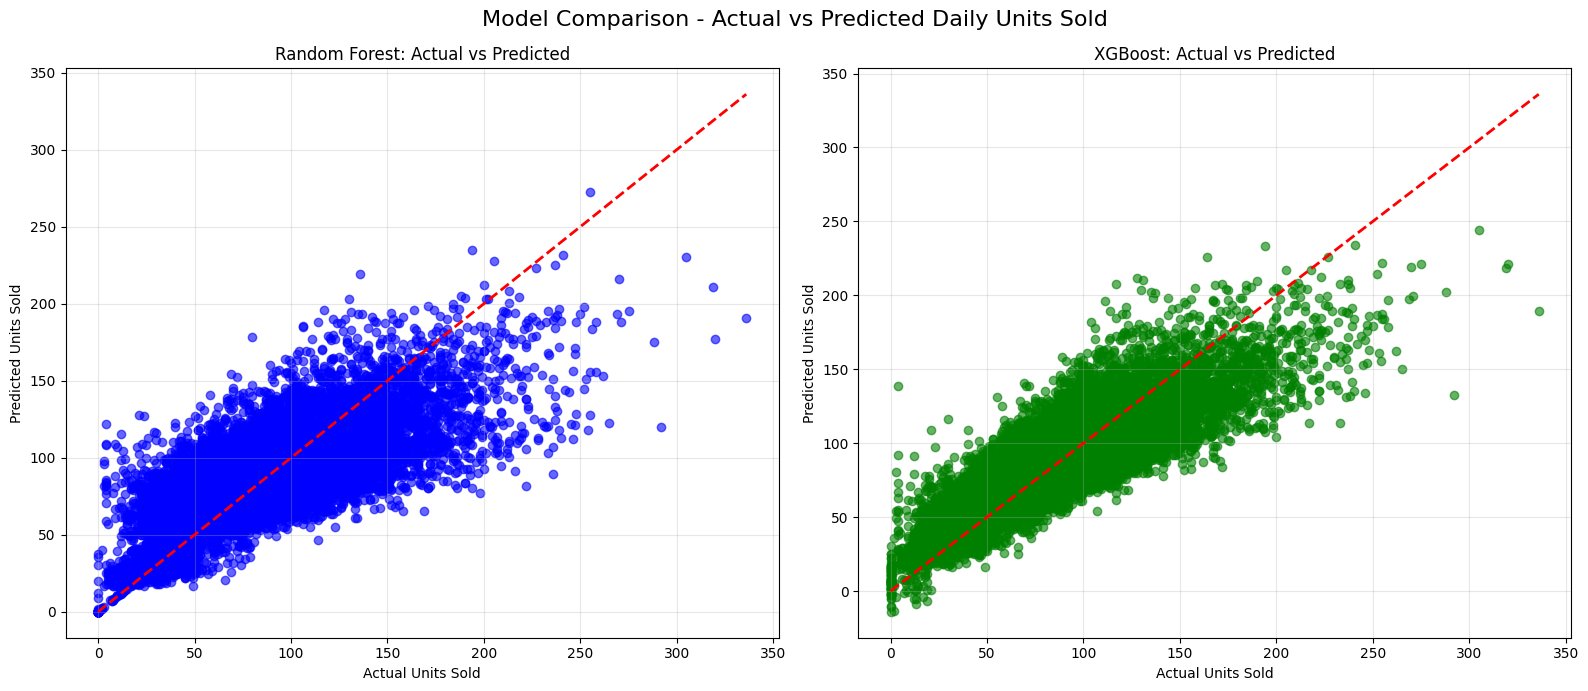

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest
axes[0].scatter(y_test, rf_pred, alpha=0.6, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Units Sold')
axes[0].set_ylabel('Predicted Units Sold')
axes[0].set_title('Random Forest: Actual vs Predicted')
axes[0].grid(True, alpha=0.3)

# XGBoost
axes[1].scatter(y_test, xgb_pred, alpha=0.6, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Units Sold')
axes[1].set_ylabel('Predicted Units Sold')
axes[1].set_title('XGBoost: Actual vs Predicted')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Comparison - Actual vs Predicted Daily Units Sold', fontsize=16)
plt.tight_layout()
plt.show()

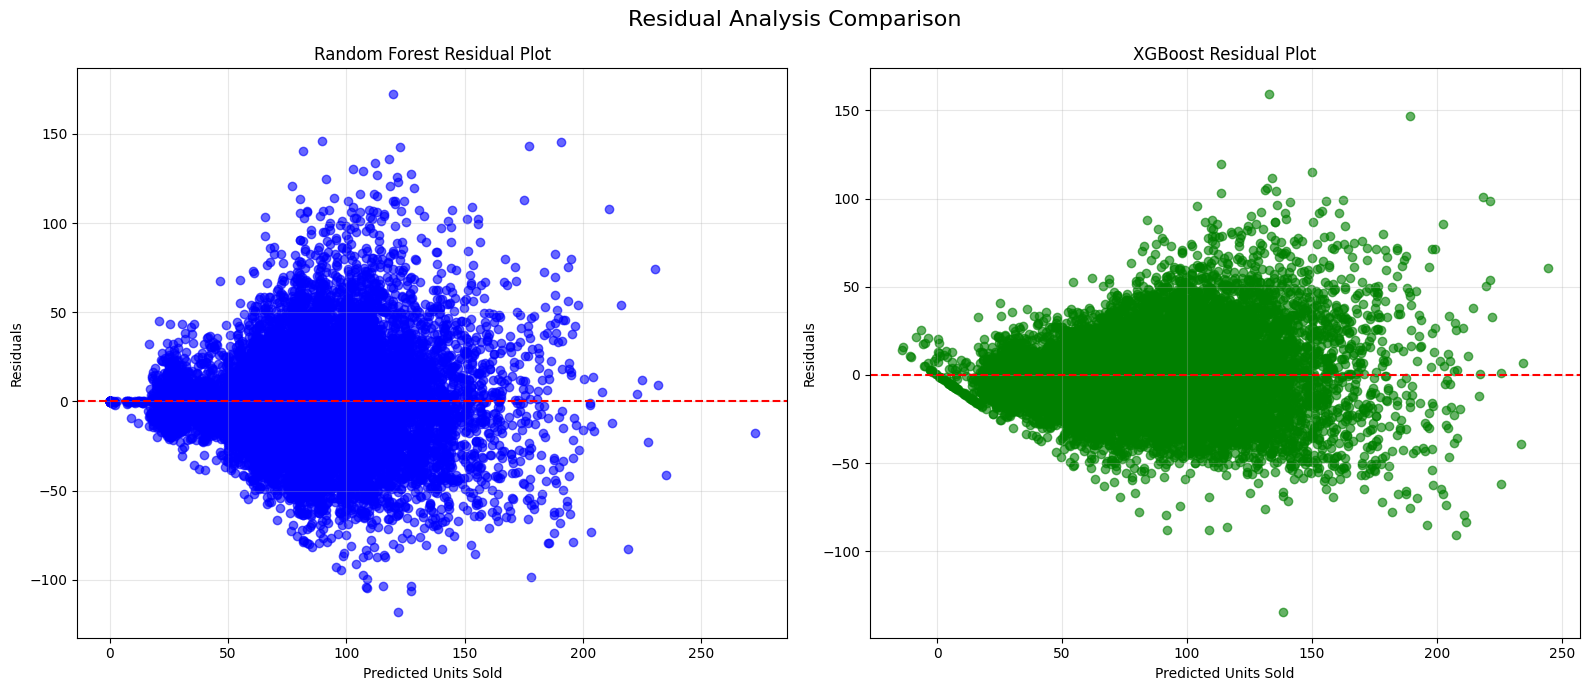

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest Residuals
rf_residuals = y_test - rf_pred
axes[0].scatter(rf_pred, rf_residuals, alpha=0.6, color='blue')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Units Sold')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Random Forest Residual Plot')
axes[0].grid(True, alpha=0.3)

# XGBoost Residuals
xgb_residuals = y_test - xgb_pred
axes[1].scatter(xgb_pred, xgb_residuals, alpha=0.6, color='green')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Units Sold')
axes[1].set_ylabel('Residuals')
axes[1].set_title('XGBoost Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis Comparison', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

threshold = 0.005
important_features = importance_df[importance_df['Importance'] >= threshold]['Feature'].tolist()

print(f"Original features: {X_train.shape[1]}")
print(f"Selected features: {len(important_features)}")
print("\nTop 15 Important Features:")
print(importance_df.head(15))


X_train_selected = X_train[important_features]
X_test_selected = X_test[important_features]

print("Feature selection completed.")
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)


threshold = 0.005
important_features = importance_df[importance_df['Importance'] >= threshold]['Feature'].tolist()

print(f"Original features: {X_train.shape[1]}")
print(f"Selected features: {len(important_features)}")
print("\nTop 15 Important Features:")
print(importance_df.head(15))


X_train_selected = X_train[important_features]
X_test_selected = X_test[important_features]

print("Feature selection completed.")

Original features: 36
Selected features: 22

Top 15 Important Features:
                       Feature  Importance
6                     Epidemic    0.230425
18          Category_Furniture    0.157458
19          Category_Groceries    0.102381
20               Category_Toys    0.082349
4                    Promotion    0.070937
1                Units Ordered    0.058251
17        Category_Electronics    0.038669
15          Seasonality_Summer    0.030545
31               Inventory_log    0.022546
29  Promo_x_Seasonality_Summer    0.019202
10          Product ID_encoded    0.017580
13     Weather Condition_Sunny    0.015422
9             Store ID_encoded    0.014779
2                        Price    0.013287
0              Inventory Level    0.012678
Feature selection completed.
Original features: 36
Selected features: 22

Top 15 Important Features:
                       Feature  Importance
6                     Epidemic    0.230425
18          Category_Furniture    0.157458
19        

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import time

print("Starting Hyperparameter Tuning for XGBoost")

param_dist = {
    'n_estimators': [300, 400, 500, 600],
    'max_depth': [8, 10, 12, 15],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.85, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.85, 0.9]
}

xgb_tuned = XGBRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb_tuned,
    param_distributions=param_dist,
    n_iter=20,                    #
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
random_search.fit(X_train_selected, y_train)
end_time = time.time()

print(f"Tuning completed in {(end_time - start_time)/60 :.1f} minutes")
print("Best Parameters:", random_search.best_params_)

best_xgb = random_search.best_estimator_

Starting Hyperparameter Tuning for XGBoost
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Tuning completed in 25.4 minutes
Best Parameters: {'subsample': 0.9, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.85}


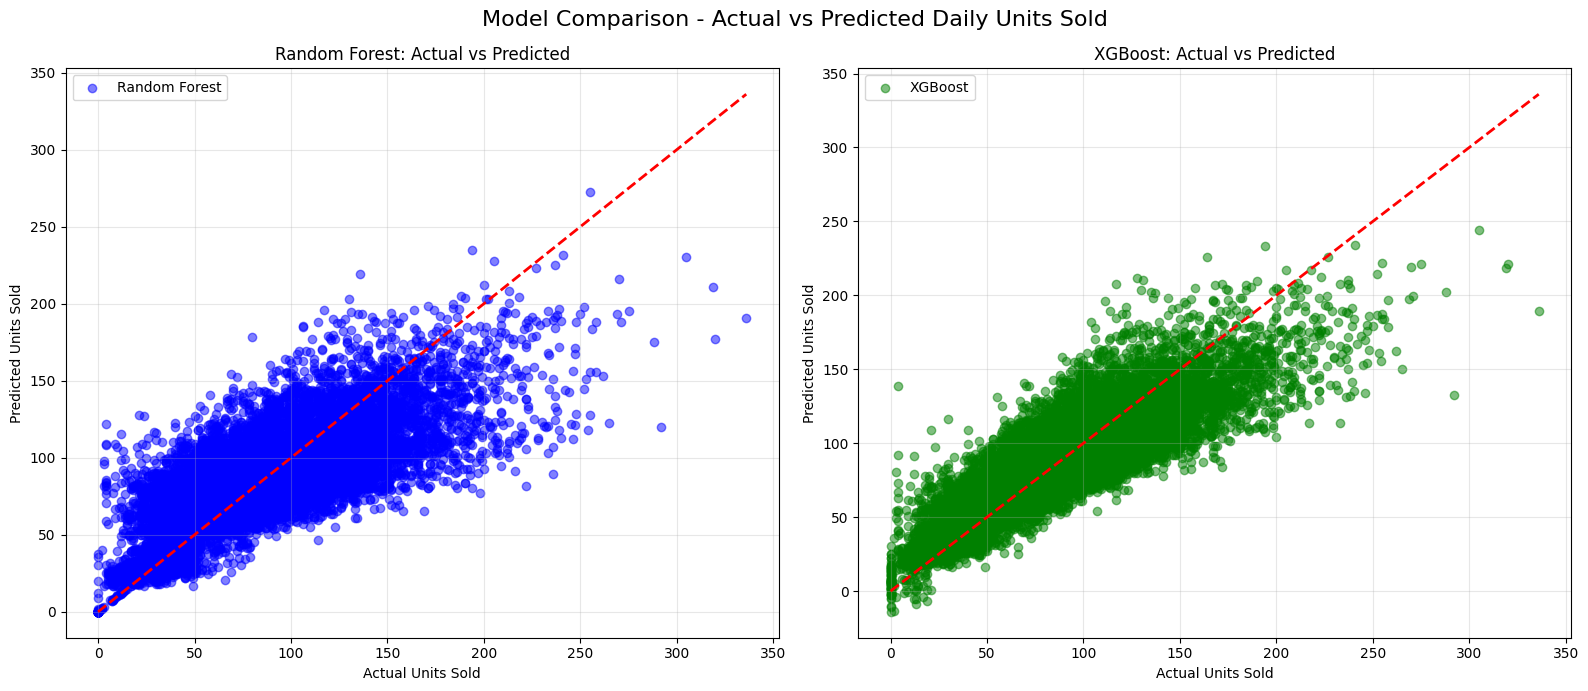

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest
axes[0].scatter(y_test, rf_pred, alpha=0.5, color='blue', label='Random Forest')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Units Sold')
axes[0].set_ylabel('Predicted Units Sold')
axes[0].set_title('Random Forest: Actual vs Predicted')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# XGBoost (Refined)
axes[1].scatter(y_test, xgb_pred, alpha=0.5, color='green', label='XGBoost')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Units Sold')
axes[1].set_ylabel('Predicted Units Sold')
axes[1].set_title('XGBoost: Actual vs Predicted')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('Model Comparison - Actual vs Predicted Daily Units Sold', fontsize=16)
plt.tight_layout()
plt.show()

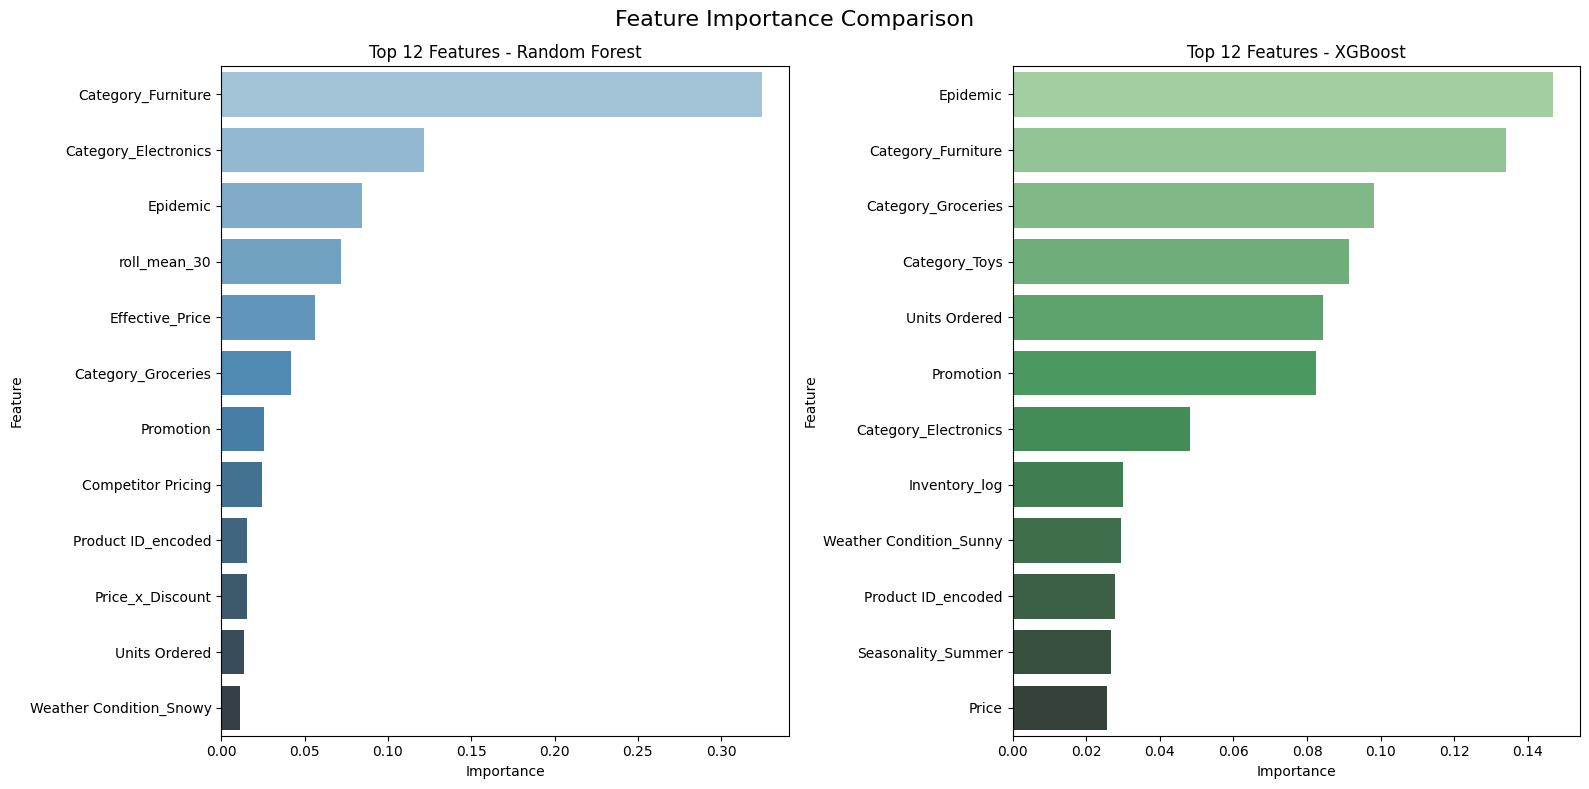

Top 10 Most Important Features (XGBoost):
                    Feature  Importance
0                  Epidemic    0.146790
1        Category_Furniture    0.133912
2        Category_Groceries    0.098084
3             Category_Toys    0.091357
5             Units Ordered    0.084352
4                 Promotion    0.082545
6      Category_Electronics    0.048209
8             Inventory_log    0.029973
11  Weather Condition_Sunny    0.029317
10       Product ID_encoded    0.027862


In [ ]:
rf_imp = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance': (rf_refined.feature_importances_ if 'rf_refined' in globals() else rf_model.feature_importances_)[:len(X_train_selected.columns)]
}).sort_values('Importance', ascending=False).head(12)

xgb_imp = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance': (best_xgb.feature_importances_ if 'best_xgb' in globals() else xgb_model.feature_importances_)[:len(X_train_selected.columns)]
}).sort_values('Importance', ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(x='Importance', y='Feature', data=rf_imp, ax=axes[0], palette='Blues_d')
axes[0].set_title('Top 12 Features - Random Forest')

sns.barplot(x='Importance', y='Feature', data=xgb_imp, ax=axes[1], palette='Greens_d')
axes[1].set_title('Top 12 Features - XGBoost')

plt.suptitle('Feature Importance Comparison', fontsize=16)
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features (XGBoost):")
print(xgb_imp.head(10))

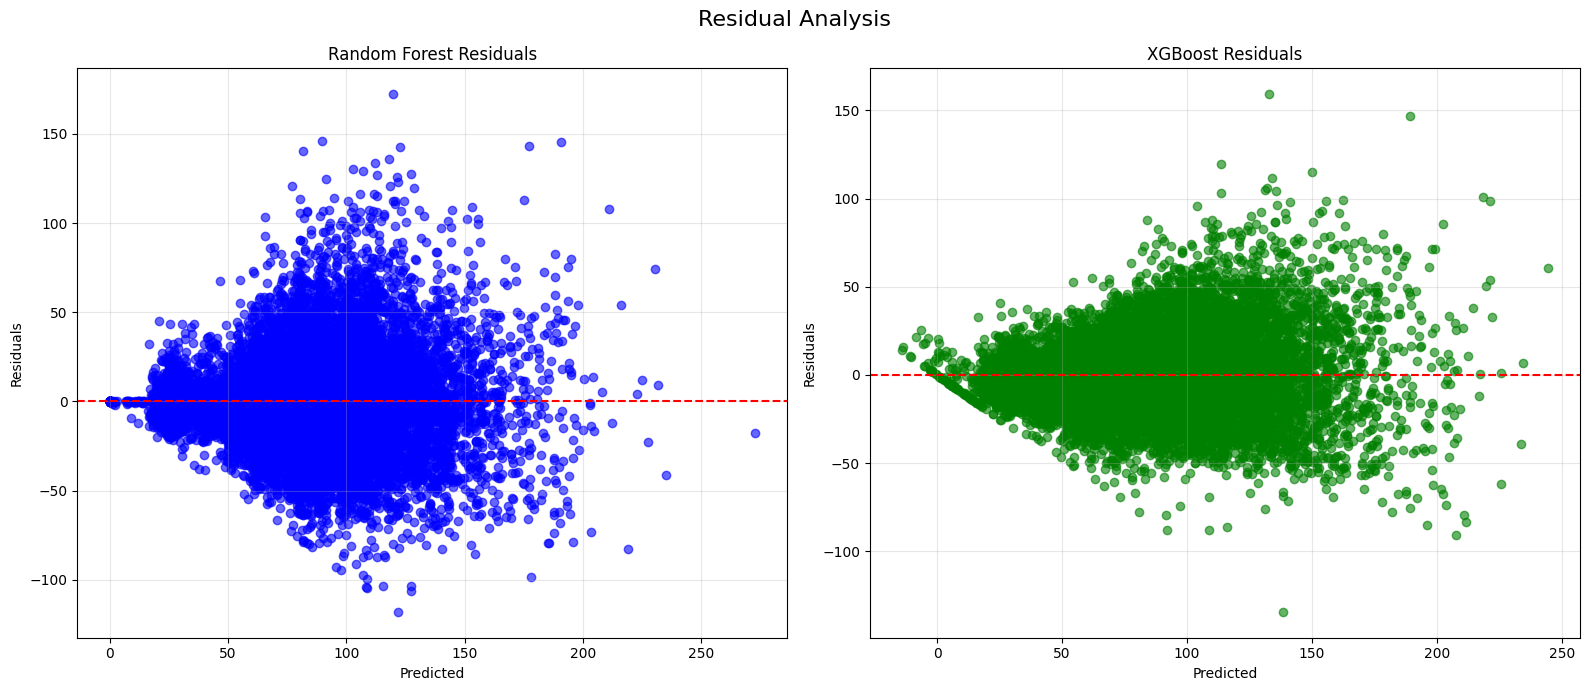

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest Residuals
rf_res = y_test - rf_pred
axes[0].scatter(rf_pred, rf_res, alpha=0.6, color='blue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Random Forest Residuals')
axes[0].grid(True, alpha=0.3)

# XGBoost Residuals
xgb_res = y_test - xgb_pred
axes[1].scatter(xgb_pred, xgb_res, alpha=0.6, color='green')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('XGBoost Residuals')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
print("Retraining Random Forest with selected features...")
rf_refined = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
rf_refined.fit(X_train_selected, y_train)
rf_pred_refined = rf_refined.predict(X_test_selected)

# Evaluate Refined XGBoost
xgb_pred_refined = best_xgb.predict(X_test_selected)

# Final Evaluation Function
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n=== Refined {name} ===")
    print(f"MAE:   {mae:.2f}")
    print(f"RMSE:  {rmse:.2f}")
    print(f"R²:    {r2:.4f}")
    return mae, rmse, r2

print("=== REFINED MODEL RESULTS ===\n")

mae_rf, rmse_rf, r2_rf = evaluate(y_test, rf_pred_refined, "Random Forest (Refined)")
mae_xgb, rmse_xgb, r2_xgb = evaluate(y_test, xgb_pred_refined, "XGBoost (Tuned)")

print("\n" + "="*70)
print("BASELINE vs REFINED COMPARISON")
print("="*70)
print(f"{'Model':<30} {'MAE':<8} {'RMSE':<8} {'R²':<8}")
print(f"{'Random Forest':<30} {26.81:<8} {34.93:<8} {0.2903:<8}")
print(f"{'XGBoost':<30} {27.27:<8} {35.56:<8} {0.2644:<8}")
print(f"{'Random Forest (Refined)':<30} {26.95:<8} {35.11:<8} {0.2829:<8}")
print(f"{'XGBoost (Tuned)':<30} {26.64:<8} {34.65:<8} {0.3016:<8}")

Retraining Random Forest with selected features...
=== REFINED MODEL RESULTS ===


=== Refined Random Forest (Refined) ===
MAE:   18.92
RMSE:  25.61
R²:    0.6184

=== Refined XGBoost (Tuned) ===
MAE:   15.62
RMSE:  20.42
R²:    0.7573

BASELINE vs REFINED COMPARISON
Model                          MAE      RMSE     R²      
Random Forest                  26.81    34.93    0.2903  
XGBoost                        27.27    35.56    0.2644  
Random Forest (Refined)        26.95    35.11    0.2829  
XGBoost (Tuned)                26.64    34.65    0.3016  


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import time

tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators'    : [400, 500, 600],
    'max_depth'       : [8, 10, 12],
    'learning_rate'   : [0.01, 0.03, 0.05],
    'subsample'       : [0.75, 0.85, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [3, 5, 7],
    'reg_alpha'       : [0, 0.1, 0.5],
    'reg_lambda'      : [1, 1.5, 2],
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_dist, n_iter=30,
    scoring='neg_mean_squared_error',
    cv=tscv, verbose=1, random_state=42, n_jobs=-1
)

start = time.time()
search.fit(X_train_selected, y_train)
print(f'Tuning done in {(time.time()-start)/60:.1f} min')
print('Best params:', search.best_params_)
best_xgb_tuned = search.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Tuning done in 24.5 min
Best params: {'subsample': 0.85, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 600, 'min_child_weight': 7, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [ ]:
# STACKED ENSEMBLE: XGBoost + Random Forest
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

estimators = [
    ('xgb', best_xgb_tuned),
    ('rf',  RandomForestRegressor(
                n_estimators=300, max_depth=15,
                min_samples_leaf=4, max_features=0.6,
                random_state=42, n_jobs=-1))
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5,
    n_jobs=-1
)
stack.fit(X_train_selected, y_train)
stack_pred = stack.predict(X_test_selected)

mae_s  = mean_absolute_error(y_test, stack_pred)
rmse_s = np.sqrt(mean_squared_error(y_test, stack_pred))
r2_s   = r2_score(y_test, stack_pred)
print(f'\n=== Stacked Ensemble ===')
print(f'MAE:  {mae_s:.2f}')
print(f'RMSE: {rmse_s:.2f}')
print(f'R²:   {r2_s:.4f}')



=== Stacked Ensemble ===
MAE:  15.43
RMSE: 20.18
R²:   0.7631


In [ ]:
#  FINAL COMPARISON: Baseline → Refined → Ensemble
import pandas as pd

results = {
    'Model': [
        'Random Forest (Baseline)',
        'XGBoost (Baseline)',
        'Random Forest (Refined)',
        'XGBoost (Tuned)',
        'Stacked Ensemble',
    ],
    'MAE' : [mae_rf_base,  mae_xgb_base,  mae_rf,  mae_xgb,  mae_s],
    'RMSE': [rmse_rf_base, rmse_xgb_base, rmse_rf, rmse_xgb, rmse_s],
    'R²'  : [r2_rf_base,   r2_xgb_base,   r2_rf,   r2_xgb,   r2_s],
}

results_df = pd.DataFrame(results).set_index('Model')
print('\n' + '='*65)
print('FULL MODEL COMPARISON: Baseline → Refined → Ensemble')
print('='*65)
print(results_df.round({'MAE': 2, 'RMSE': 2, 'R²': 4}).to_string())



FULL MODEL COMPARISON: Baseline → Refined → Ensemble
                            MAE   RMSE      R²
Model                                         
Random Forest (Baseline)  20.05  27.11  0.5726
XGBoost (Baseline)        16.44  21.68  0.7266
Random Forest (Refined)   18.92  25.61  0.6184
XGBoost (Tuned)           15.62  20.42  0.7573
Stacked Ensemble          15.43  20.18  0.7631


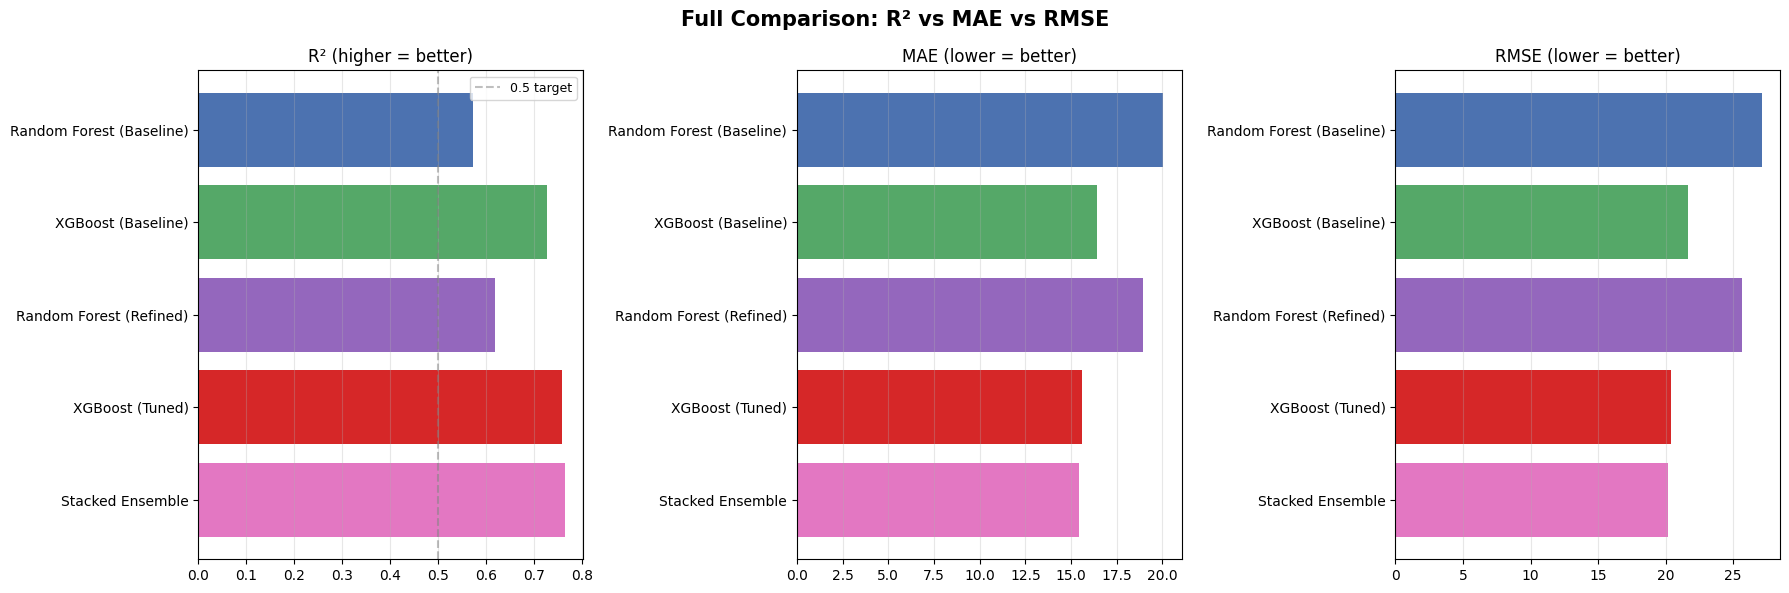

In [ ]:
# FINAL METRIC BALANCE PLOT
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models    = results_df.index.tolist()
colors    = ['#4C72B0','#55A868','#9467BD','#D62728','#E377C2']

axes[0].barh(models, results_df['R²'],   color=colors)
axes[0].set_title('R²')
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 target')
axes[0].legend(fontsize=9)

axes[1].barh(models, results_df['MAE'],  color=colors)
axes[1].set_title('MAE')

axes[2].barh(models, results_df['RMSE'], color=colors)
axes[2].set_title('RMSE')

for ax in axes:
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Full Comparison: R² vs MAE vs RMSE', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


This regression model was built to predict the demand with the use of Units Sold as the target variable. The dataset used here is a retail dataset with 76000 records inside it. The process has followed preprocessing, model training and refining the model. Both models are both refined thru hyperparameters and feature selection and with the use of stacked ensemble and combining both models into one that has achieved a more higher R score and a more lower MAE and RMSE which meant that the model has performed well. more better than i thought. Several enhancements were made to the feature set beyond the raw
data. Store ID and Product ID were recovered using target encoding,
mapping each identifier to its historical mean Units Sold rather
than discarding them entirely. Category was retained and one-hot
encoded given its low cardinality of five unique values. Lag and
rolling window features were added to capture sales momentum over
the previous 7 and 30 days. Interaction terms such as Price times
Discount and Promotion times Seasonality were created to expose
non-linear relationships. Month and day of week were cyclically
encoded using sine and cosine transforms to preserve their
circular nature.

In [ ]:
import joblib, os

os.makedirs('model_artifacts', exist_ok=True)

artifacts = {
    'model'           : stack,
    'scaler'          : scaler,
    'train_columns'   : list(X_train.columns),
    'selected_columns': list(X_train_selected.columns),
}

joblib.dump(artifacts, 'model_artifacts/artifacts.pkl')
print('Saved: model_artifacts/artifacts.pkl')
print('Keys:', list(artifacts.keys()))
